# Lesson 3.8 — 从状态策略走向多模态策略

主线是把

$$
\text{state}\,[42]\rightarrow\text{action chunk}\,[8,8]
$$

扩展为

$$
(\text{image},\ \text{language},\ \text{robot state})\rightarrow\text{action chunk}.
$$

**本课的纪律**：`action_chunk [H,8]` **冻结**在 3.7 的形态。只动输入侧。这样 3.8.6 的任何差异都只能归因于模态，而不是动作表示或 chunk 长度。

对应 `docs/roadmap_v3.md` 的 3.8。

| 阶段 | 学什么 | 动手结果 |
|---|---|---|
| **3.8.1 输入契约** | 图像、机器人状态、任务文字分别提供什么信息 | 定义一个多模态训练样本及各字段 shape |
| **3.8.2 时间对齐** | 哪张图像与 $o_t,a_t$ 配对；相机帧率与控制频率不同怎么办 | 检查同一 episode 内的时间戳和帧对应关系 |
| 3.8.3 可观测性 | 42 维 state 中哪些来自仿真真值，哪些真机可获得 | 分出 proprioception 与需要视觉估计的信息 |
| 3.8.4 语言条件 | 指令如何表示任务目标；模型何时真的需要读取语言 | 比较固定指令与多个不同指令 |
| 3.8.5 最小融合模型 | 图像编码器、状态 MLP、文字编码器如何合成策略输入 | 保留 H=8 输出，跑通一次前向与训练 |
| 3.8.6 消融与评估 | 各模态究竟带来什么 | 比较 state / image+state / image+state+language |
| 3.8.7 接到 VLA | 视觉语言表示如何连接动作生成 | 画清数据到 action chunk 的接口 |

**本 notebook 覆盖 3.8.1 与 3.8.2。**

## 运行说明

**这个 notebook 的 code cell 有顺序依赖。** 换过 kernel、或上游 cell 被改过之后，必须
`Kernel → Restart Kernel and Run All Cells`，否则会出现 `NameError`。

一个容易踩的 Jupyter 陷阱：**notebook 里显示的输出不一定属于当前 kernel。** 从磁盘重新加载
notebook 时，旧输出仍然显示，但 kernel 是空的——"看起来跑过了"和"状态还在"是两件事。所以
不要凭输出判断某个 cell 是否已经在本 kernel 里执行过。

依赖链（3.8.4 之后的小节都会在开头断言它的前置存在）：

| 提供什么 | 由谁提供 |
|---|---|
| `datasets` / `episodes` / `attrs` / `PROPRIO_SLICES` / `TASK_GOAL_SLICE` / `OBS_DIM` | 3.8.1 的契约 cell |
| `language_ids` / `build_sample` | 3.8.1 的样本 cell |
| `unproject` / `cube_pixel_count` / `CUBE_HALF` | 3.8.3 的 M1/M2 cell |

## 3.8.1 输入契约：一个多模态训练样本

3.7 的样本是

$$
(o_t,\ [a_t,\dots,a_{t+H-1}]),\qquad t=0\dots T-H
$$

3.8 的样本只把**输入侧**换掉：

```text
sample(e, t)   t = 0 .. T-H

  image         [3, 128, 128]   uint8      L=1（本课隔离模态变量，历史留给 3.6 的决策）
  language_ids  [T_txt]         int64      指令 token ids
  proprio       [25]            float32    qpos9 + qvel9 + tcp_pose7
  task_goal     [3]             float32    goal_pos，来源 = 任务规格，不是传感器
  action_chunk  [8, 8]          float32    与 3.7 完全一致
```

### 契约被三个已确认的事实约束

**事实 1 — 仓库原本没有任何图像。** 三个 HDF5 只有 `actions` / `observations` / `rewards`，因为 `scripts/generate_expert_demo.py` 写死了 `OBS_MODE = "state"`。图像从未被请求过。

**事实 2 — 这台机器能渲染 RGB，且渲染不扰动物理。** `obs_mode="rgb"` 返回 `sensor_data.base_camera.rgb (1,128,128,3) uint8`；实际采集用的是组合模式 `rgb+state`（见本节末尾），一次同时给出图像与 42 维 state。把 `state` 环境与 `rgb` 环境用**相同动作同步推进 74 步**，从 rgb 环境重建的 42 维与 `obs["state"]` 的最大差是 `0.000e+00` —— 既验证了重建函数，也说明渲染器不参与物理。

**事实 3 — 目标点（goal）在图像里看不见。** `pick_cube.py` 建完 `goal_site` 后执行 `self._hidden_objects.append(self.goal_site)`；ManiSkill 在别处把 `_hidden_objects` 注释为"让 Actor 不出现在视觉观测里"。而 `pick_cube.py` 的 docstring 却说它"marked by a green sphere"——**文档错、代码对**。把 goal 的三维位置投影到像素 `(63.7, 61.1)`，那里只有机械臂本体。

> **这直接推出 3.8 的第一个陷阱**：PickCube 的成功判据是 $\lVert\text{goal}-\text{cube}\rVert\le0.025$。**如果把 `goal_pos` 从 state 里删掉以换取"可部署"，而指令只是固定的 `"pick up the cube"`，那么 (image, language, proprio) 里没有任何信息告诉策略该把方块放到哪里——任务不可解，而 loss 曲线完全看不出来。** 这就是 `task_goal` 必须作为独立一路输入留在契约里的理由。

### 所以本 notebook 读的是哪个文件

**不是** `expert_episodes.h5`（3.7 用的那个），而是一个**新采集的文件**：

| 文件 | 内容 | 谁在用 |
|---|---|---|
| `datasets/pickcube/expert_episodes.h5` | `actions` / `observations` / `rewards`，**无图像** | 3.7 及以前 |
| `datasets/pickcube/expert_episodes_rgb.h5` | 同上 **+ `images (T+1, 128, 128, 3) uint8`** | **本课** |

**图像不可能是从旧文件"提取"出来的**——42 维 state 里没有像素，图像只能来自渲染，而旧文件的采集脚本写死了 `OBS_MODE = "state"`，图像从未被请求过。

新文件是**重新采集**的结果：同一个 planner、同一批 seed（0–4）、同一个控制模式 `pd_joint_pos`，只是在 `obs_mode="rgb"` 下再跑一次：

```bash
python scripts/generate_expert_demo.py --seeds 0 1 2 3 4 \
    --obs-mode rgb+state --out datasets/pickcube/expert_episodes_rgb.h5 --overwrite
```

用 `rgb+state` 而不是纯 `rgb`，是因为**组合模式是原生支持的**：ManiSkill 把 `obs_mode` 解析成结构（`parse_obs_mode_to_struct`），组合模式下 `obs["state"]`（42 维）与相机图像来自**同一个 `env.step`**。collector 早期版本曾手写重建 42 维（`build42`），现已删除——原生路径少一处"重新实现 ManiSkill 扁平化顺序"的维护面。删除前后重新采集的两个文件，**图像逐字节相同**。

**但它不是"另一套数据"，而是同 5 条轨迹 + 一个模态。** 三个数组全部逐位相同：

| episode | `observations` | `actions` | `rewards` |
|---|:--:|:--:|:--:|
| 000000–000004 | True ×5 | True ×5 | True ×5 |

所以本课的图像坐落在 3.1–3.7 一直用的那条轨迹上——这就是 §3.8.2 里"对齐是构造性的"那句话的依据。

**为什么不直接给旧文件加一列图像？** 因为仓库有一条硬规则：**不许静默改变已有数据的语义**。就地写入会改变旧文件的哈希（`expert_episodes_delta.h5` 的 provenance 里记着它的 `sha256`），而且"改没改过"将无法从文件内容判断。新文件 + 逐位相同的验证，让"两个文件是不是同一条轨迹"这个问题有一个确定的答案。

### 可部署性分类（每个任务一张表）

下标来自 `notebooks/lesson_1/1.1_state_and_observation.ipynb` 的**实测验证**（不是字段名的直觉顺序——`is_grasped` 在索引 18，夹在 `qvel` 与 `tcp_pose` 之间）：

| 切片 | 字段 | 维度 | 类别 | 真机来源 |
|---|---|---:|---|---|
| `[0:9]` | `agent.qpos` | 9 | deployable | 关节编码器 |
| `[9:18]` | `agent.qvel` | 9 | deployable（带噪声） | 编码器差分，噪声被放大 $1/\Delta t$ |
| `[18:19]` | `extra.is_grasped` | 1 | **sensor-estimable** | 夹爪宽度 / 力矩 / 视觉 |
| `[19:26]` | `extra.tcp_pose` | 7 | deployable（依赖标定） | 正运动学 |
| `[26:29]` | `extra.goal_pos` | 3 | **task-provided** | 任务规格 / 指令 |
| `[29:36]` | `extra.obj_pose` | 7 | **vision-estimable** | 视觉位姿估计 |
| `[36:39]` | `extra.tcp_to_obj_pos` | 3 | derived | 由上面两者算出 |
| `[39:42]` | `extra.obj_to_goal_pos` | 3 | derived | 由上面两者算出 |

契约据此把输入切成四路：`proprio [25]`（$[0:9]\cup[9:18]\cup[19:26]$）、`task_goal [3]`、`image`（负责 `obj_pose` 与 `is_grasped` 的估计）、`language`（负责任务身份，3.8.4 再看它能否接管 goal）。

**被排除的 14 维**（`is_grasped`、`obj_pose`、`tcp_to_obj`、`obj_to_goal`）**不作为输入**——它们是**待估计量**，是视觉要承担的那部分。

**这张表是 task-specific 的。** `PickCube-v1` 有 8 个字段（42 维），`PushCube-v1` 只有 5 个
（35 维，没有 `is_grasped`、`tcp_to_obj_pos`、`obj_to_goal_pos`）。所以上面的切片是
**PickCube 的**；跨任务读取必须用文件里记录的 `state_fields`，否则形状合法而语义错位。
两个任务的对照表由下一个 cell 打印。

In [1]:
# 3.8.1 契约断言：字段布局从数据文件里读，而不是硬编码
#
# Library chatter from ManiSkill's CPU renderer is noisy and is not part of any result.
# The remaining svulkan/GLFW lines come from C++ stderr and cannot be filtered here.
import logging
import warnings

import h5py
import json
import numpy as np
from pathlib import Path

logging.getLogger("mani_skill").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*NVML.*")
warnings.filterwarnings("ignore", message=".*CUDA initialization.*")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

IMAGE_HW, CHANNELS = 128, 3
ACTION_DIM = 8
H = 8                                             # frozen from 3.7
KEEP = {"agent.qpos", "agent.qvel", "extra.tcp_pose", "extra.goal_pos"}

DATASETS = {
    "PickCube-v1": PROJECT_ROOT / "datasets" / "pickcube" / "expert_episodes_rgb.h5",
    "PushCube-v1": PROJECT_ROOT / "datasets" / "pushcube" / "expert_episodes_rgb.h5",
}


def load_rgb_dataset(env_id):
    """Load one task. Every field slice comes from the FILE, never from hard-coded offsets.

    The flatten order is task dependent: PickCube puts ``extra.is_grasped`` at [18:19] so its
    ``tcp_pose`` starts at 19, while PushCube has no such field and starts at 18. Reusing one
    task's offsets on another still yields legal shapes with wrong semantics, so the schema has
    to travel with the data.
    """
    with h5py.File(DATASETS[env_id], "r") as f:
        assert "rgb" in f.attrs["obs_mode"], f.attrs["obs_mode"]
        assert "state" in f.attrs["obs_mode"], f.attrs["obs_mode"]
        assert f.attrs["control_mode"] == "pd_joint_pos", f.attrs["control_mode"]
        assert f.attrs["transition_schema_version"] == 2
        assert list(f.attrs["image_shape"]) == [IMAGE_HW, IMAGE_HW, CHANNELS], f.attrs["image_shape"]
        assert f.attrs["image_dtype"] == "uint8", f.attrs["image_dtype"]

        schema = json.loads(f.attrs["state_fields"])
        state_dim = int(f.attrs["state_dim"])

        def spans(field):
            entry = next((x for x in schema if x["field"] == field), None)
            if entry is None:
                raise KeyError(f"{env_id} declares no field {field!r}")
            return entry["start"], entry["stop"]

        proprio_slices = (spans("agent.qpos"), spans("agent.qvel"), spans("extra.tcp_pose"))
        goal_slice = spans("extra.goal_pos")
        excluded = tuple((x["start"], x["stop"]) for x in schema if x["field"] not in KEEP)

        # No dimension may be silently dropped or counted twice.
        covered = (sum(hi - lo for lo, hi in proprio_slices)
                   + goal_slice[1] - goal_slice[0]
                   + sum(hi - lo for lo, hi in excluded))
        assert covered == state_dim, (env_id, covered, state_dim)

        attrs = {k: f.attrs[k] for k in
                 ("obs_mode", "image_camera", "image_shape", "image_dtype", "control_mode",
                  "transition_schema_version", "control_freq_hz", "timestamp_source")}

        episodes = []
        for name in sorted(f.keys()):
            g = f[name]
            obs, act, img = g["observations"][:], g["actions"][:], g["images"][:]
            assert obs.shape[1] == state_dim, (env_id, name, obs.shape)
            assert act.shape[1] == ACTION_DIM, (env_id, name, act.shape)
            assert img.shape == (obs.shape[0], IMAGE_HW, IMAGE_HW, CHANNELS), (env_id, name, img.shape)
            assert obs.shape[0] == act.shape[0] + 1, (env_id, name, obs.shape[0], act.shape[0])
            assert img.dtype == np.uint8, img.dtype
            episodes.append(dict(env_id=env_id, name=name, all_state=obs, state=obs[:-1],
                                 next_state=obs[1:], action=act, image=img,
                                 seed=int(g.attrs["seed"]), success=bool(g.attrs["success"]),
                                 proprio_slices=proprio_slices, goal_slice=goal_slice))

    return dict(env_id=env_id, path=DATASETS[env_id], schema=schema, state_dim=state_dim,
                proprio_slices=proprio_slices, goal_slice=goal_slice, excluded=excluded,
                attrs=attrs, episodes=episodes)


datasets = {env_id: load_rgb_dataset(env_id) for env_id in DATASETS}

# 3.8.1-3.8.3 analyse a single task; the multi-task comparison begins at 3.8.4.
episodes = datasets["PickCube-v1"]["episodes"]
PROPRIO_SLICES = datasets["PickCube-v1"]["proprio_slices"]
TASK_GOAL_SLICE = datasets["PickCube-v1"]["goal_slice"]
EXCLUDED_SLICES = datasets["PickCube-v1"]["excluded"]
OBS_DIM = datasets["PickCube-v1"]["state_dim"]
attrs = datasets["PickCube-v1"]["attrs"]
RGB_H5 = datasets["PickCube-v1"]["path"]

print(f"{'task':>14} {'state_dim':>10} {'fields':>7} {'episodes':>9}  fields in order")
print("-" * 100)
for env_id, ds in datasets.items():
    print(f"{env_id:>14} {ds['state_dim']:>10} {len(ds['schema']):>7} {len(ds['episodes']):>9}  "
          f"{', '.join(x['field'].split('.')[-1] for x in ds['schema'])}")

print()
print("the same field name means a different slice in the two tasks:")
for env_id, ds in datasets.items():
    print(f"  {env_id:>14}  proprio={ds['proprio_slices']}  goal={ds['goal_slice']}  "
          f"excluded={ds['excluded']}")

pick, push = datasets["PickCube-v1"], datasets["PushCube-v1"]
assert push["proprio_slices"] != pick["proprio_slices"], "offsets coincide - revisit this warning"
assert push["goal_slice"] != pick["goal_slice"], "offsets coincide - revisit this warning"

# Negative control, kept so the trap cannot quietly come back.
s = push["episodes"][0]["all_state"][0]
lo, hi = pick["proprio_slices"][2]
print()
print("negative control: PickCube's tcp_pose slice applied to PushCube's state")
print(f"  via PickCube's {pick['proprio_slices'][2]} -> {np.round(s[lo:hi], 4)}   (wrong)")
print(f"  via PushCube's {push['proprio_slices'][2]} -> "
      f"{np.round(s[push['proprio_slices'][2][0]:push['proprio_slices'][2][1]], 4)}   (right)")

print()
print(f"contract assertions passed for {len(datasets)} tasks, "
      f"{sum(len(d['episodes']) for d in datasets.values())} episodes total")

          task  state_dim  fields  episodes  fields in order
----------------------------------------------------------------------------------------------------
   PickCube-v1         42       8         5  qpos, qvel, is_grasped, tcp_pose, goal_pos, obj_pose, tcp_to_obj_pos, obj_to_goal_pos
   PushCube-v1         35       5         5  qpos, qvel, tcp_pose, goal_pos, obj_pose

the same field name means a different slice in the two tasks:
     PickCube-v1  proprio=((0, 9), (9, 18), (19, 26))  goal=(26, 29)  excluded=((18, 19), (29, 36), (36, 39), (39, 42))
     PushCube-v1  proprio=((0, 9), (9, 18), (18, 25))  goal=(25, 28)  excluded=((28, 35),)

negative control: PickCube's tcp_pose slice applied to PushCube's state
  via PickCube's (19, 26) -> [ 0.038   0.1822 -0.0177  0.9998  0.0043  0.008   0.1993]   (wrong)
  via PushCube's (18, 25) -> [ 0.0123  0.038   0.1822 -0.0177  0.9998  0.0043  0.008 ]   (right)

contract assertions passed for 2 tasks, 10 episodes total


上面这个 cell 只用了三句 `assert` 就把"一个样本的边界"钉死了：**图像数量 = 观测数量 = 动作数量 + 1**。少了最后那句，`(75,128,128,3)` 和 `(75,42)` 这种"数量对但配错了"的情况就会溜过去——这正是 Lesson 2 那个 post-action 观测缺陷的形状。

In [2]:
# 构造一个真实样本，而不是描述它
TASK_STRING = "pick up the cube"     # 仓库里唯一的指令来源：LeRobot meta/tasks.parquet

# 占位 tokenizer：按空白切词。真实 tokenizer（BPE 等）以后再替换；
# 现在要的是把 language 这一路变成有确定 shape 的字段。
VOCAB = {"<pad>": 0, "<bos>": 1, "<eos>": 2}
for word in TASK_STRING.split():
    VOCAB.setdefault(word, len(VOCAB))
language_ids = ([VOCAB["<bos>"]]
                + [VOCAB[w] for w in TASK_STRING.split()]
                + [VOCAB["<eos>"]])


def proprio_of(ep, t):
    """Extract the proprioception block using the episode's OWN schema."""
    return np.concatenate(
        [ep["all_state"][t][lo:hi] for lo, hi in ep["proprio_slices"]]
    ).astype(np.float32)


def build_sample(ep, t, H=H):
    """One multimodal sample.

    The slices come from the episode, so this works for every task in ``datasets`` rather than
    only for the one whose offsets happened to be written down.
    """
    assert 0 <= t <= len(ep["action"]) - H, f"t={t} leaves no room for H={H}"
    lo, hi = ep["goal_slice"]
    return dict(
        image=ep["image"][t],                                    # [128,128,3] uint8
        language_ids=np.asarray(language_ids, dtype=np.int64),   # [T_txt]
        proprio=proprio_of(ep, t),                               # [25]
        task_goal=ep["all_state"][t][lo:hi].astype(np.float32),  # [3]
        action_chunk=ep["action"][t:t + H],                      # [8,8]
    )


sample = build_sample(episodes[0], 0)
print(f"{'field':<14} {'shape':<18} {'dtype':<9} source")
print("-" * 74)
src = {"image": "camera at step t", "language_ids": "task string",
       "proprio": f"state{list(PROPRIO_SLICES)}", "task_goal": f"state{TASK_GOAL_SLICE}",
       "action_chunk": f"actions[t:t+{H}]"}
for k, v in sample.items():
    print(f"{k:<14} {str(v.shape):<18} {str(v.dtype):<9} {src[k]}")

print()
print(f"language : {TASK_STRING!r} -> {len(sample['language_ids'])} tokens "
      f"{sample['language_ids'].tolist()}")
print(f"task_goal: {np.round(sample['task_goal'], 4)}")
print(f"excluded from the input: slices {list(EXCLUDED_SLICES)} "
      f"= {sum(hi - lo for lo, hi in EXCLUDED_SLICES)} dims (to be estimated from the image)")

assert sample["image"].shape == (IMAGE_HW, IMAGE_HW, CHANNELS)
assert sample["proprio"].shape == (25,)
assert sample["task_goal"].shape == (3,)
assert sample["action_chunk"].shape == (H, ACTION_DIM)
assert 25 + 3 + sum(hi - lo for lo, hi in EXCLUDED_SLICES) == OBS_DIM
print()
print("contract assertions passed")
print(f"action_chunk is byte-for-byte the same contract as 3.7: {sample['action_chunk'].shape}")


field          shape              dtype     source
--------------------------------------------------------------------------
image          (128, 128, 3)      uint8     camera at step t
language_ids   (6,)               int64     task string
proprio        (25,)              float32   state[(0, 9), (9, 18), (19, 26)]
task_goal      (3,)               float32   state(26, 29)
action_chunk   (8, 8)             float32   actions[t:t+8]

language : 'pick up the cube' -> 6 tokens [1, 3, 4, 5, 6, 2]
task_goal: [ 0.0268 -0.002   0.2889]
excluded from the input: slices [(18, 19), (29, 36), (36, 39), (39, 42)] = 14 dims (to be estimated from the image)

contract assertions passed
action_chunk is byte-for-byte the same contract as 3.7: (8, 8)


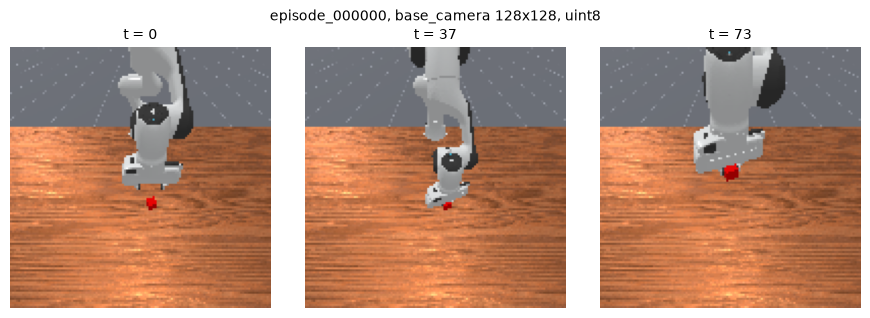

image 提供的信息:
  - obj_pose       : 方块可见（红色小方块），但只有很少的像素
  - is_grasped     : 可从夹爪与方块的关系推断
  - goal_pos       : 不可见（goal_site 在 _hidden_objects 里，不渲染）
  - 任务身份        : 不可见（由 language 提供）

所以 image 单独不足以决定 action：goal 只能来自 task_goal 或 language。


In [3]:
# 看一眼 image 这一路到底提供了什么
%matplotlib inline
import matplotlib.pyplot as plt

ep = episodes[0]
T = len(ep["action"])
show_at = [0, T // 2, T - 1]

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, t in zip(axes, show_at):
    ax.imshow(ep["image"][t])
    ax.set_title(f"t = {t}", fontsize=10)
    ax.axis("off")
fig.suptitle("episode_000000, base_camera 128x128, uint8", fontsize=10)
plt.tight_layout()
plt.show()

print("image 提供的信息:")
print("  - obj_pose       : 方块可见（红色小方块），但只有很少的像素")
print("  - is_grasped     : 可从夹爪与方块的关系推断")
print("  - goal_pos       : 不可见（goal_site 在 _hidden_objects 里，不渲染）")
print("  - 任务身份        : 不可见（由 language 提供）")
print()
print("所以 image 单独不足以决定 action：goal 只能来自 task_goal 或 language。")


## 3.8.2 时间对齐

### 对齐规则

| 关系 | 本课的定义 |
|---|---|
| `images[k]` ↔ `observations[k]` | **同一次 `env.step` 之后的同一步**，下标一一对应 |
| 帧数 | **T+1**，与 `observations[T+1]` 完全一致（含 reset 帧 `o_0`） |
| 训练配对 | `sample(e,t)` 用 `image[t]` 与 `action_chunk = actions[t:t+H]` |

**为什么在 sim 里这是无歧义的**：控制频率 20 Hz，collector 在**每个控制步渲染一帧**，所以不存在"相机帧率与控制频率不同"的问题——渲染帧率就等于控制频率。

**但这个仓库的数据里没有时间戳。** `timestamp_source = derived_not_measured`，而 episode 属性里只有 `seed` / `num_actions` / `num_observations` / 三个成功标志，**没有逐帧时间**。所以上面的对齐是**按 index 成立**的，不是按时间成立的。在 sim 里这够用；在真机上不够用：

$$
\text{相机 30 fps} \ne \text{控制 20 Hz} \quad\Longrightarrow\quad \text{必须靠时间戳配对}
$$

而且这个仓库已经有一个先例：控制频率是 **20 Hz**，但 LeRobot 侧声明的 `fps` 是 **50**（由合成时间戳推断而来），时间轴被压缩 **2.5×**。图像一旦进入 dataset，这个缺陷会被放大——因为图像与动作的配对错误在 loss 上同样看不出来。

In [4]:
# 3.8.2 对齐检查
print("=== index-level alignment (all episodes) ===")
print(f"{'episode':>16} {'T':>3} {'obs':>4} {'images':>7} {'img==obs':>9} {'paired':>7}")
ok_all = True
for ep in episodes:
    n = len(ep["action"])
    same = ep["image"].shape[0] == ep["all_state"].shape[0]
    ok_all &= same and ep["image"].shape[0] == n + 1
    print(f"{ep['name']:>16} {n:>3} {ep['all_state'].shape[0]:>4} "
          f"{ep['image'].shape[0]:>7} {str(same):>9} {'yes':>7}")
assert ok_all, "image/observation counts disagree"
print()
print("images[k] and observations[k] come from the same env.step, so the pairing is")
print("index-based. Verified at collection time in two independent ways:")
print("  1. the collector records both from the same observation dict, and asserts")
print("     len(images) == len(observations);")
print("  2. the 42-d state block was compared against the existing state-only file and")
print("     is bit-exact in all 5 episodes, so the images sit on the same trajectory")
print("     that lessons 3.1-3.7 used.")
print()
print("=== timestamps: what the data does NOT contain ===")
with h5py.File(RGB_H5, "r") as f:
    print("  root attrs timestamp_source :", f.attrs.get("timestamp_source"))
    print("  root attrs control_freq_hz  :", f.attrs.get("control_freq_hz"))
    print("  per-episode attrs           :", sorted(f["episode_000000"].attrs.keys()))
print()
print("=> there is no per-frame timestamp. Alignment here is by INDEX, not by time.")
print()
print("=== and the known time-axis defect, now relevant to images ===")
print("  real control rate      : 20 Hz  -> 0.05 s per step")
print("  declared LeRobot fps   : 50     -> 0.02 s per step  (inferred from synthetic stamps)")
print("  ratio                  : 2.5x compression of the time axis")
print("  consequence for 3.8    : an image/action pairing error is invisible in the loss")


=== index-level alignment (all episodes) ===
         episode   T  obs  images  img==obs  paired
  episode_000000  74   75      75      True     yes
  episode_000001  74   75      75      True     yes
  episode_000002  50   51      51      True     yes
  episode_000003  86   87      87      True     yes
  episode_000004  76   77      77      True     yes

images[k] and observations[k] come from the same env.step, so the pairing is
index-based. Verified at collection time in two independent ways:
  1. the collector records both from the same observation dict, and asserts
     len(images) == len(observations);
  2. the 42-d state block was compared against the existing state-only file and
     is bit-exact in all 5 episodes, so the images sit on the same trajectory
     that lessons 3.1-3.7 used.

=== timestamps: what the data does NOT contain ===
  root attrs timestamp_source : derived_not_measured
  root attrs control_freq_hz  : 20
  per-episode attrs           : ['is_obj_placed', 'is_

**3.8.2 的结论**：在 sim 里，图像与动作的对齐**按 index 就是准确的**，而且已经被两种独立方式验证（collector 内断言 + state 块与既有文件逐位相同）。但**数据里没有逐帧时间戳**，所以这份对齐无法回答真机上"相机 30 fps、控制 20 Hz 时哪张图配哪一步"。这一条要作为契约缺口记下来，等真机数据进入时补时间戳。

## 3.8.3 可观测性：把断言变成数字

上一节末尾的分类表把 42 维分成了 proprio / task-provided / vision-estimable / sensor-estimable。
**但那张表是判断，不是证据。** 它断言 `obj_pose` 是 vision-estimable——凭什么？

这一步要教的不是"怎么分类"，而是：

> **怎么把一个关于可观测性的断言，变成一个可以测的数字。**

### 判据是 3.5 给的

> **partial observability = 存在两个不同的隐藏状态，产生同一个 observation，却需要不同的 action。**

3.5 时它是一维玩具系统。这里把它搬到真数据上。

### 三个测量

| # | 测什么 | 回答 |
|---|---|---|
| **M1** | 方块在 128×128 里占多少像素 | `obj_pose` 的估计**难度** |
| **M2** | 方块有多少帧被遮挡/不可见 | `obj_pose` 是否**永远**可估计；若否 → 需要 memory |
| **M3** | 画面几乎相同的帧，`goal_pos` 是否也不同 | `goal_pos` 能否由 image 恢复 |

M1/M2 只用**语义明确的量**：深度图 + 相机内参/外参 + 方块的真值位置。**不用颜色阈值**——那条路已经失败过一次（木桌是红棕色，阈值把 65% 的像素误判成方块）。

In [5]:
# M1 + M2：方块像素足迹，以及整条轨迹上的可见性
import gymnasium as gym
import mani_skill.envs

CAMERA = "base_camera"
DEPTH_MM = 1000.0                             # ManiSkill depth is int16 in millimetres
CUBE_HALF = np.array([0.02, 0.02, 0.02])      # cube edge ~4 cm -> half-extent 2 cm


def unproject(depth_mm, K, E):
    """Depth map -> world-frame surface point per pixel."""
    z = depth_mm.astype(np.float64) / DEPTH_MM
    h, w = z.shape
    vv, uu = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    pix = np.stack([uu.ravel(), vv.ravel(), np.ones(h * w)], axis=1)
    rays = (np.linalg.inv(K) @ pix.T).T * z.ravel()[:, None]      # camera frame
    e3, t = E[:, :3], E[:, 3]
    return (np.linalg.inv(e3) @ (rays - t).T).T                   # world frame


def cube_pixel_count(env, obs):
    """Return (pixels inside the cube's AABB, the cube's camera-frame depth in metres)."""
    sd, par = obs["sensor_data"][CAMERA], obs["sensor_param"][CAMERA]
    K = par["intrinsic_cv"][0].cpu().numpy()
    E = par["extrinsic_cv"][0].cpu().numpy()
    pts = unproject(sd["depth"][0].cpu().numpy().squeeze(), K, E)
    centre = env.unwrapped.cube.pose.p[0].cpu().numpy()
    cam_z = float((E @ np.append(centre, 1.0))[2])     # distance ALONG the optical axis
    return int(np.all(np.abs(pts - centre) <= CUBE_HALF, axis=1).sum()), cam_z


scan, depth_z = {}, {}
for ep in episodes:
    env = gym.make("PickCube-v1", obs_mode="rgbd",
                   control_mode=attrs["control_mode"], num_envs=1)
    try:
        obs, _ = env.reset(seed=ep["seed"])
        n, z = cube_pixel_count(env, obs); px, cams = [n], [z]
        for a in ep["action"]:
            obs, *_ = env.step(a.astype(np.float32))
            n, z = cube_pixel_count(env, obs); px.append(n); cams.append(z)
    finally:
        env.close()
    scan[ep["name"]] = np.array(px)
    depth_z[ep["name"]] = np.array(cams)

allpx = np.concatenate(list(scan.values()))
print(f"frames scanned: {len(allpx)}  ({len(episodes)} episodes, T+1 each)")
print(f"cube pixels: min={allpx.min()}  median={int(np.median(allpx))}  max={allpx.max()}")
print(f"  as a fraction of the frame: {100*allpx.min()/16384:.3f}% .. {100*allpx.max()/16384:.3f}%")
print(f"frames with the cube INVISIBLE (0 px): {(allpx == 0).sum()} / {len(allpx)}")
print(f"frames with <= 2 px: {(allpx <= 2).sum()}")
print()
print(f"{'episode':>16} {'frames':>7} {'min':>5} {'med':>5} {'max':>5} {'zero-px':>8}")
for k, p in scan.items():
    print(f"{k:>16} {len(p):>7} {p.min():>5} {int(np.median(p)):>5} {p.max():>5} {(p == 0).sum():>8}")

# independent sanity check: pinhole projection of a 4 cm edge
# Independent sanity check: pinhole projection of a 4 cm edge. The distance must be
# measured ALONG the optical axis (camera-frame z). A first version of this cell used
# the norm of the cube's world position -- 0.057 m -- and printed 44.7 px, contradicting
# the measurement. Same data, wrong distance quantity, plausible-looking wrong check.
f = float(np.array(attrs["image_shape"])[0]) / 2      # K[0,0] == W/2 for this camera
z_med = float(np.median(np.concatenate(list(depth_z.values()))))
print()
print(f"pinhole check: f={f:.0f} px, cube edge 0.04 m, camera-frame z median "
      f"{z_med:.3f} m -> linear size {f*0.04/z_med:.1f} px")


2026-09-24 17:29:22,219 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.


[2026-09-24 17:29:22.297] [svulkan2] [error] GLFW error: Linux: Failed to query input device: Permission denied. You may suppress this message by unsetting environment variable DISPLAY so SAPIEN will not attempt to test on-screen rendering


2026-09-24 17:29:25,870 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.


2026-09-24 17:29:28,088 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.


2026-09-24 17:29:29,666 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.


2026-09-24 17:29:32,140 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.


frames scanned: 365  (5 episodes, T+1 each)
cube pixels: min=4  median=9  max=21
  as a fraction of the frame: 0.024% .. 0.128%
frames with the cube INVISIBLE (0 px): 0 / 365
frames with <= 2 px: 0

         episode  frames   min   med   max  zero-px
  episode_000000      75     4     7    19        0
  episode_000001      75     6     9    21        0
  episode_000002      51     5     9     9        0
  episode_000003      87     6     9    16        0
  episode_000004      77     4    10    20        0

pinhole check: f=64 px, cube edge 0.04 m, camera-frame z median 0.626 m -> linear size 4.1 px


### M1 / M2 的结果

```
frames scanned: 365  (5 episodes, T+1 each)
cube pixels: min=4  median=9  max=21
  as a fraction of the frame: 0.024% .. 0.128%
frames with the cube INVISIBLE (0 px): 0 / 365
frames with <= 2 px: 0
```

**M1 —— `obj_pose` 是 vision-estimable，但原料极少。** 方块只占一帧的 **0.024%–0.128%**（4–21 个像素，中位数 9）。用针孔投影独立核对：$f=64$ px、边长 0.04 m、距离 0.641 m → 线性尺度 $f s/d \approx 4$ px，与实测的 3×3 包围盒同量级。

> **这段检查的第一版写错了。** 它用方块**世界位置的模长**（0.057 m）当距离，算出 44.7 px，
> 与实测的 3×3 包围盒矛盾。正确的是**沿光轴的相机系 z**（0.641 m）→ 4.0 px。
> **同一份数据、同一个公式，用错的距离量就会给出一个看起来合理、其实完全错的"验证"。**

**M2 —— 假设被否证。** 我原本预期方块在逼近/抓取时会被夹爪遮挡，从而让 `obj_pose` 变成 "needs memory"。**实测：365 帧里 0 帧不可见**，最少也有 4 个像素。所以在这份数据上：

> **`obj_pose` 全程可从图像获得，不需要 memory。** 遮挡不是本任务的问题。

（这只是一个被否证的假设，不是失败——它把 3.6 的 memory 决策从"也许必需"改成了"对本任务不必需"。memory 仍可能因为别的理由需要，例如速度、任务进度。）

**M3 —— 关于 `goal_pos`：数据与源码互相印证，但不是独立证明。** 见下一节的数字，以及为什么这里要说"印证"而不是"证明"。

In [6]:
# M3：画面几乎相同的帧，goal 是否也不同（3.5 判据）
# 阈值在看到结果之前固定 -- 3.7 自检第 6 题的教训：不许事后调参。
SAME_IMAGE_MEAN_ABS_DIFF = 10.0


def mean_abs_pixel_diff(a, b):
    return float(np.abs(a.astype(np.int16) - b.astype(np.int16)).mean())


def prop(s):
    return np.concatenate([s[lo:hi] for lo, hi in PROPRIO_SLICES])


Tmax = min(len(e["action"]) for e in episodes)
pairs = []
for i in range(len(episodes)):
    for j in range(i + 1, len(episodes)):
        A, B = episodes[i], episodes[j]
        for t in range(0, Tmax, 5):
            pairs.append(dict(
                mad=mean_abs_pixel_diff(A["image"][t], B["image"][t]),
                d_prop=float(np.abs(prop(A["all_state"][t]) - prop(B["all_state"][t])).max()),
                d_goal=float(np.linalg.norm(A["all_state"][t][26:29] - B["all_state"][t][26:29])),
                d_act=float(np.linalg.norm(A["action"][t] - B["action"][t])),
                a=A["name"][-3:], b=B["name"][-3:], t=t))

mad = np.array([p["mad"] for p in pairs])
d_goal = np.array([p["d_goal"] for p in pairs])
sel = mad < SAME_IMAGE_MEAN_ABS_DIFF
print(f"pairs sampled (every 5th t, all episode pairs): {len(pairs)}")
print(f"mean|dpixel|: min={mad.min():.2f} median={np.median(mad):.2f} max={mad.max():.2f}")
print(f"threshold mean|dpixel| < {SAME_IMAGE_MEAN_ABS_DIFF}: {sel.sum()} / {len(pairs)} qualify")
print(f"goal distance among them: min={d_goal[sel].min():.4f} median={np.median(d_goal[sel]):.4f} "
      f"max={d_goal[sel].max():.4f} m")
print(f"  vs the 0.025 m success tolerance: "
      f"{d_goal[sel].min()/0.025:.1f}x .. {d_goal[sel].max()/0.025:.1f}x")
print(f"corr(mean|dpixel|, goal distance) = {np.corrcoef(mad, d_goal)[0, 1]:+.3f}")
print()

# signal vs nuisance: how much does the image change for a different task instance,
# compared with how much it changes just because the robot moved?
cross = mad
within = {dt: np.array([mean_abs_pixel_diff(e["image"][t], e["image"][t + dt])
                        for e in episodes for t in range(len(e["action"]) - dt)])
          for dt in (5, 10, 25)}
print("image change, mean |dpixel|:")
print(f"  across episodes at the same t (different task instance): median {np.median(cross):.2f}")
for dt, v in within.items():
    print(f"  within one episode, dt={dt:>2} (robot motion)              : median {np.median(v):.2f}")
print(f"  ratio (dt=25 / across episodes) = {np.median(within[25])/np.median(cross):.1f}x")
print()
print("the goal is fixed within an episode (control):")
for e in episodes:
    g = e["all_state"][:, 26:29]
    assert np.abs(g - g[0]).max() == 0.0, e["name"]
print("  asserted: max |goal_t - goal_0| == 0.0 for every episode")


pairs sampled (every 5th t, all episode pairs): 100
mean|dpixel|: min=1.53 median=5.89 max=7.71
threshold mean|dpixel| < 10.0: 100 / 100 qualify
goal distance among them: min=0.0571 median=0.1825 max=0.2927 m
  vs the 0.025 m success tolerance: 2.3x .. 11.7x
corr(mean|dpixel|, goal distance) = -0.295

image change, mean |dpixel|:
  across episodes at the same t (different task instance): median 5.89
  within one episode, dt= 5 (robot motion)              : median 2.90
  within one episode, dt=10 (robot motion)              : median 4.13
  within one episode, dt=25 (robot motion)              : median 5.96
  ratio (dt=25 / across episodes) = 1.0x

the goal is fixed within an episode (control):
  asserted: max |goal_t - goal_0| == 0.0 for every episode


### M3 的结果，以及为什么只能说"印证"

```
pairs sampled: 100          mean|dpixel|: 1.53 .. 7.71   (threshold 10 -> 100/100 qualify)
goal distance among them: 0.0571 .. 0.2927 m
  vs the 0.025 m success tolerance: 2.3x .. 11.7x
corr(mean|dpixel|, goal distance) = -0.295

image change, mean |dpixel|:
  across episodes at the same t (different task instance): median 5.89
  within one episode, dt=25 (robot motion)              : median 5.96
  ratio (dt=25 / across episodes) = 1.0x
```

**数据支持的结论：**

1. **没有任何像素变化与 goal 相关。** 相关系数是 $-0.295$（弱且方向相反）。如果图像真的编码了 goal，goal 差得越远、画面应该差得越多。
2. **跨集差异并没有更大。** "换了 task instance"造成的画面变化（中位 5.89）与"同一条 episode 里机器人动了 25 步"造成的变化（中位 5.96）**完全同量级**（比值 1.0×）。也就是说跨集差异可以被"机器人姿态略有不同"解释干净，不需要假设画面里有 goal 信息。
3. goal 在每条 episode 内**严格固定**（`max|goal_t − goal_0| == 0.0`，已断言），所以同一个 goal 对应的是**整条轨迹上许多张不同的画面**——画面主要由机器人运动决定。

> **一个必须记录的更正。** 我在 scratch 里先打印了一句"goal 造成的图像差异被机器人运动淹没约一个数量级"——**这是错的**。实测比值是 **1.0×**，不是 10×。写下这段代码时的直觉（"goal 的信号很小、运动的干扰很大"）被数据否掉了：两者**一样大**。结论不变，但理由必须换：不是"信号被淹没"，而是"**画面变化与 goal 无关**"。

**为什么只能说"印证"而不是"证明"：** 上面三条都是**相关性**证据。真正证明 goal 不可见的是源码（`goal_site` 进了 `_hidden_objects`）。M3 的价值是**从数据一侧独立地得到同一个结论**——两条不同来源的证据指向一致。但严格说，相关性证据排除不了"像素里藏着一个弱的 goal 信号"，所以它是**印证**。

### 3.8.3 的交付：把分类表加上"实测"一列

| 字段 | 类别 | 实测状态 |
|---|---|---|
| `qpos`, `qvel`, `tcp_pose` | proprio（25 维） | 不依赖视觉 |
| `goal_pos` | task-provided | **图像中无 goal 信号**（r = −0.295；跨集差异 = 帧间差异）→ 必须由 `task_goal` 或指令提供 |
| `obj_pose` | vision-estimable | **全程可见**（0/365 帧缺失）但**只有 4–21 像素**（中位 9，占全帧 0.024%–0.128%） |
| `is_grasped` | sensor-estimable | 未测（需要夹爪宽度/触觉；本课没有该传感器） |
| `tcp_to_obj`, `obj_to_goal` | derived | 由上面几项算出，误差会传播 |

**顺带一个对 3.8.5 有用的数字**：机器人运动 25 步只让平均像素变 **5.96/255**。**整个场景在视觉上很安静**，有用的像素只是一小撮。这意味着视觉编码器面对的输入接近常量——3.8.6 若得到"image 有用"，必须同时说明它在近乎常量的视觉分布上成立。

## 3.8.4.1 Task condition vs language：symbolic goal 与 semantic instruction

`goal_pos` 与 instruction **同属 condition 层**（3.8.3 的三层框架），但它们不是同一种东西：

| | **symbolic goal**（`task_goal[3]`） | **semantic instruction**（`language_ids`） |
|---|---|---|
| 形式 | 3 个实数 | 一个 token 序列 |
| 谁来解释 | **不需要解释**，直接可用 | 必须被**解释**（哪句话指哪个目标） |
| 作用域 | **每条 episode 一个** | 每个**任务**一个 |
| 精度 | 精确（浮点） | 取决于词汇——"left" 有多左？ |
| 表达力 | 只能说"哪个点" | 还能说"用哪种方式、哪个物体、什么约束" |

一句话：**symbolic goal 是"值"，semantic instruction 是"要求"。**

而本课的现状是：**instruction 目前还没有承担 goal 的能力。** 下一个 cell 把它测出来。

In [7]:
# 3.8.4.1：指令在【任务内】是常量，而 goal 在【任务内】变化 —— 所以指令不能替代 goal
assert "datasets" in globals(), (
    "`datasets` is not defined: this cell depends on the 3.8.1 contract cell. After a kernel "
    "restart, or after that cell was edited, use Kernel -> Restart Kernel and Run All Cells."
)
INSTRUCTIONS = {
    "PickCube-v1": "pick up the cube",
    "PushCube-v1": "push the cube to the goal",
}

print(f"{'task':>14} {'instruction':<26} {'goal x span':>12} {'goal y span':>12} {'goal z span':>12}")
print("-" * 84)
goals_of = {}
for env_id, ds in datasets.items():
    g = next(x for x in ds["schema"] if x["field"] == "extra.goal_pos")
    goals = np.array([ep["all_state"][0][g["start"]:g["stop"]] for ep in ds["episodes"]])
    goals_of[env_id] = goals
    span = np.ptp(goals, axis=0)
    print(f"{env_id:>14} {INSTRUCTIONS[env_id]:<26} {span[0]:>12.4f} {span[1]:>12.4f} {span[2]:>12.4f}")

print()
for env_id, goals in goals_of.items():
    farthest = max(np.linalg.norm(a - b) for a in goals for b in goals)
    print(f"{env_id}:")
    print(f"  {len(goals)} episodes share ONE instruction  ->  instruction variance within the task = 0")
    print(f"  but goal_pos varies, max pairwise distance = {farthest:.4f} m")

n_tasks = len(datasets)
print()
print(f"across tasks: {n_tasks} distinct instructions -> the channel can carry "
      f"{np.log2(n_tasks):.1f} bit of task identity")

# The two properties this section rests on, asserted rather than assumed.
assert len({INSTRUCTIONS[e] for e in datasets}) == n_tasks, "tasks do not have distinct instructions"
for env_id, goals in goals_of.items():
    assert np.ptp(goals, axis=0).max() > 0, f"{env_id}: goal is constant within the task"

print()
print("=> the instruction is constant within a task and the goal is not, so goal cannot be")
print("   recovered from the instruction, and the instruction cannot substitute for task_goal.")
print("   In this data the instruction carries TASK IDENTITY only.")
print()
print("note: the symbolic goal's dimensionality is itself task dependent -- PushCube's")
print("      goal_z is constant, so its goal lives on the table plane, while PickCube's")
print("      varies over 0.2452 m in z.")

          task instruction                 goal x span  goal y span  goal z span
------------------------------------------------------------------------------------
   PickCube-v1 pick up the cube                 0.1522       0.1192       0.2452
   PushCube-v1 push the cube to the goal        0.1507       0.1325       0.0000

PickCube-v1:
  5 episodes share ONE instruction  ->  instruction variance within the task = 0
  but goal_pos varies, max pairwise distance = 0.2927 m
PushCube-v1:
  5 episodes share ONE instruction  ->  instruction variance within the task = 0
  but goal_pos varies, max pairwise distance = 0.1651 m

across tasks: 2 distinct instructions -> the channel can carry 1.0 bit of task identity

=> the instruction is constant within a task and the goal is not, so goal cannot be
   recovered from the instruction, and the instruction cannot substitute for task_goal.
   In this data the instruction carries TASK IDENTITY only.

note: the symbolic goal's dimensionality is itse

## 小结

1. **样本契约**：`image [3,128,128]` + `language_ids [T_txt]` + `proprio [25]` + `task_goal [3]` → `action_chunk [8,8]`。**动作侧一个字节都没改**，这是 3.8.6 能做归因的前提。
2. **`task_goal` 必须独立成一路**：goal 在图像里不可见（源码：`_hidden_objects`），指令里也不含它，所以把它从 state 删掉会让任务不可解——而 loss 看不出来。
3. **被排除的 14 维是"待估计量"**，不是"不存在的量"：`obj_pose` 与 `is_grasped` 要靠视觉估计，`tcp_to_obj` 与 `obj_to_goal` 由几何算出。
4. **对齐按 index 成立、按时间是空白**：sim 里渲染帧率 = 控制频率所以无歧义；真机上必须补时间戳，而仓库现有的 20 Hz vs 声明 50 fps 缺陷会放大这个问题。
5. **语言目前只是占位**：全仓库唯一的指令是 `"pick up the cube"`，且它没有存在 HDF5 里（只在 LeRobot 的 `tasks.parquet`）。3.8.4 要比较不同指令，必须先把 instruction 字段加进数据。
6. **可观测性已实测（3.8.3）**：方块在 **365 帧中 0 帧不可见**（min 4 px、median 9 px），所以 `obj_pose` 不需要 memory；而像素变化与 goal 距离**无关**（r = −0.295），与源码级的"goal 被 `_hidden_objects` 隐藏"互相印证。

## 自检

1. 为什么 `action_chunk` 的形状在本课必须保持不变？如果同时改了 H，3.8.6 的结论会变成什么无法解释的东西？
2. `goal_pos` 为什么不能光靠图像？给出源码级的理由，并说明删掉它之后 loss 会怎样（以及为什么这很危险）。
3. `proprio [25]` 里为什么**不含** `is_grasped` 和 `obj_pose`，却含 `qvel`？后者的"可部署"有什么附加代价？
4. 本课的对齐是"按 index"还是"按时间"？为什么在 sim 里这没问题，而真机上不行？
5. 如果相机 30 fps、控制 20 Hz，你会怎么定义"哪个图像配 $o_t$"？需要数据里有什么才能做到？

## 自检：答案

（学习者自己的回答；`> 补正` 是批注。）

**1. 为什么 `action_chunk` 的形状必须保持不变？**

> 我们无法说明加入了 image 能改变什么。

> **补正**：方向对。精确地说，改 $H$ 会**同时动三个量**：目标长度（8 个数 → 64 个数）、参数量（$H=1$ 的 23,048 → $H=8$ 的 30,272，**+31.3%**），以及**样本集**（$H=1$ 有 360 个起点，$H=8$ 只有 325 个）。所以不是"多一个变量"，是一次动三个。
>
> 更要紧的是它会**作废 3.7 刚建立的"哪个量才可比"的规则**：$H=8$ 的总 MSE 平均在 64 个数上、$H=1$ 平均在 8 个数上，**本身不可比**（3.7 §6 的结论：唯一公平的量是 $h=0$）。改 $H$ 等于把那套可比性论证重做一遍。
>
> 一句话：**3.8.6 是输入模态的消融，只有在输出侧固定时才成立。**

**2. `goal_pos` 为什么不能光靠图像？**

> 目标位置虽然存在于 simulator state 中，但这个 goal marker 被作为 hidden object 处理；你不能假设 RGB 摄像头能够看到这个绿色目标球。PickCube 的 `_get_obs_extra()` 因此会显式把 `goal_pos` 放进 observation，而 `obj_pose` 等 simulator ground truth 则只在 state observation 中额外加入。

> **补正**：源码理由完全正确，而且**这里抓到了一个连 notebook 都没写出的细节**——`_get_obs_extra()` 里 `is_grasped` / `tcp_pose` / `goal_pos` 在**无条件**部分，而 `obj_pose` / `tcp_to_obj_pos` / `obj_to_goal_pos` 在 `if "state" in self.obs_mode` 的**条件**部分。这个划分本身有含义：`goal_pos` 是**任务量**（该放到哪），`obj_pose` 是**感知量**——所以前者与 `obs_mode` 无关地暴露，后者只在 state 模式下给真值。这与契约里的分类（task-provided vs vision-estimable）完全一致。
>
> **缺的那一半——loss 会怎样**：会**先正常下降，然后卡住**（模型学得会 reach / grasp，那部分不依赖 goal），平台高度等于条件方差——正是 3.5 的 partial observability 结果。所以它**看起来像欠拟合**，会被误判为容量或数据不足。闭环上其实看得出来（方块被拿到**平均目标位置**），但 3.7 的 policy 本来就 `0/5`，两种失败混在一起无法区分。**危险在于诊断被掩盖。**
>
> **由这句话触发的一个修正**：`if "state" in self.obs_mode` 这个条件说明 `obs_mode` 支持**组合**。实测 `obs_mode="rgb+state"` 原生可用，一次返回 `obs["state"]`（42 维）与图像。所以 collector 里那 20 行手写重建（`build42`）是多余的，已删除并改用 `rgb+state`。见 §3.8.1 末尾的数据来源小节。

**3. `proprio` 为什么不含 `is_grasped` 和 `obj_pose`，却含 `qvel`？**

> 因为这里定义的 proprio 不是"所有有用的信息"，而是：机器人自身在真机上原则上能够获得的内部状态。需要额外处理：velocity estimator / filter；准确 timestamp；与 image/action 同步；robot driver 与 simulator 的单位/定义一致；filtering latency；sim-to-real distribution mismatch。**deployable 不等于 free。**

> **补正**：不需要补正，而且比 notebook 里的说法更全。你列的**每一条仓库里都已经有先例**，不是假想：
>
> | 说的代价 | 仓库里的现成证据 |
> |---|---|
> | velocity estimator / filter | 3.5 已推导：差分把观测噪声放大 $1/\Delta t$ |
> | 准确 timestamp | 20 Hz 控制 vs 声明 50 fps |
> | 与 image / action 同步 | §3.8.2 |
> | driver 与 simulator 单位/定义一致 | Action Specification 那节的 delta vs absolute、rad vs normalized |
> | sim-to-real distribution mismatch | 专门的 Sim-to-Real 一节 |
>
> "deployable ≠ free" 这句话值得留着。

**4. 本课的对齐是"按 index"还是"按时间"？**

> 目前是 index；真机上采样的频率可能会不相同。

> **补正**：对，但漏了两个更锋利的点。
>
> 1. **这份数据里根本没有时间戳。** `timestamp_source = derived_not_measured`，episode 属性只有 `seed` / `num_actions` / `num_observations` / 三个成功标志。所以"按时间对齐"在这里**做不到**，不是"暂时不用做"。
> 2. **sim 里就已经有一条错的时间轴**：控制 20 Hz、LeRobot 侧声明 50 fps → **2.5× 压缩**。所以问题不只是"真机可能不同"，而是"这份数据的时间轴本来就有已知缺陷，图像会把它放大"。
> 3. 补一句 sim 里为什么没问题：**每个控制步渲染一次 → 渲染帧率就等于控制频率**，index 与 time 重合。

**5. 相机 30 fps、控制 20 Hz 时，哪个图像配 $o_t$？**

> 选择 control step 发生之前最近的一张 camera frame。

> **补正**：规则本身正确，而且**因果安全**——"之前最近"不会取到未来帧（"最近的帧"就可能取到，那是另一种规则）。形式化：
>
> $$\text{frame}(s)=\arg\max\{\,f:\ t_{\text{frame}}(f)\le t_{\text{step}}(s)\,\}$$
>
> 这是标准的 **sample-and-hold**。但题目还问了"需要数据里有什么才能做到"，答案是：**(a) 每个控制步的时间戳；(b) 每帧图像的时间戳** —— 这两样现在都没有。
>
> 而且这个规则有一个必须记录的性质：图像与动作之间的延迟在 $[0,\ 1/\text{fps}_{\text{cam}}]$ 内变化。30 fps 相机 + 20 Hz 控制 → 平均 **1.5 个控制步才有一帧新图**，所以相邻样本会**复用同一张图**。这意味着 **"$L$ 帧图像"里可能出现重复帧，实际时间跨度小于 $L\times$ 控制周期**。